# Machine Translation with Attention

English-to-French sequence-to-sequence translation using the local additive-attention model and data pipeline.

In [6]:
import collections
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'src').is_dir() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.mt.data import DataLoaderConfig, MTData, MTDataInput
from src.mt.model import (
    Seq2SeqAttentionDecoder,
    Seq2SeqAttentionDecoderInputs,
    Seq2SeqEncoder,
    Seq2SeqInputs,
)

## Prepare the corpus

`MTData` downloads the archive only when missing, normalizes punctuation, tokenizes sentence pairs, builds `Vocab` instances, pads sequences, and creates train/validation loaders.

In [7]:
DATA_URL = 'https://www.manythings.org/anki/fra-eng.zip'
MAX_STEPS = 20
BATCH_SIZE = 256
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
mt_data = MTData(
    MTDataInput(
        DATA_URL,
        zip_data=True,
        max_steps=MAX_STEPS,
        data_dir=PROJECT_ROOT / 'notebooks' / 'data',
    )
)
mt_data.download_and_extract()
raw_text = mt_data.read_data('fra.txt')
source_tokens, target_tokens = mt_data.tokenize(mt_data.preprocess(raw_text))
train_loader, validation_loader = mt_data.build_dataloaders(
    source_tokens,
    target_tokens,
    DataLoaderConfig(80, 20, BATCH_SIZE),
)

print(f'{len(source_tokens):,} sentence pairs')
print(f'{len(mt_data.src_vocab):,} source tokens; {len(mt_data.tgt_vocab):,} target tokens')
source_tokens[:3], target_tokens[:3]

240,521 sentence pairs
11,228 source tokens; 19,213 target tokens


([['go', '.', '<eos>'], ['go', '.', '<eos>'], ['go', '.', '<eos>']],
 [['va', '!', '<eos>'],
  ['marche', '.', '<eos>'],
  ['en', 'route', '!', '<eos>']])

In [8]:
source, source_lengths, target, target_lengths = next(iter(train_loader))
print(source.shape, source_lengths.shape, target.shape, target_lengths.shape)
print(mt_data.src_vocab.to_tokens(source[0].tolist()))
print(mt_data.tgt_vocab.to_tokens(target[0].tolist()))

torch.Size([256, 20]) torch.Size([256]) torch.Size([256, 20]) torch.Size([256])
["i'd", 'like', 'to', 'confirm', 'our', 'reservations', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<bos>', "j'aimerais", 'confirmer', 'nos', 'réservations', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


## Attention encoder-decoder

The bidirectional encoder emits a forward/backward representation for every source token. At each target step, the decoder scores those states with additive attention, masks source padding using `source_lengths`, and combines the resulting context with the target embedding.

In [9]:
EMBEDDING_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.1
LEARNING_RATE = 1e-3
EPOCHS = 15
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
MODEL_PATH = PROJECT_ROOT / 'translation_model.pt'

encoder = Seq2SeqEncoder(
    Seq2SeqInputs(
        len(mt_data.src_vocab), EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT
    )
).to(DEVICE)
decoder = Seq2SeqAttentionDecoder(
    Seq2SeqAttentionDecoderInputs(
        len(mt_data.tgt_vocab), EMBEDDING_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT
    )
).to(DEVICE)
model = nn.ModuleList((encoder, decoder))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
PAD_INDEX = mt_data.tgt_vocab['<pad>']
loss_function = nn.CrossEntropyLoss(ignore_index=PAD_INDEX, reduction='sum')
print(f'Training on {DEVICE}')

Training on mps


In [10]:
def show_progress(phase, current, total, loss_sum, tokens, started):
    width = 30
    filled = width * current // total
    bar = '#' * filled + '-' * (width - filled)
    elapsed = max(time.perf_counter() - started, 1e-9)
    print(
        f'\r{phase:<10} [{bar}] {current}/{total} '
        f'loss={loss_sum / max(tokens, 1):.4f} '
        f'tokens/s={tokens / elapsed:,.0f}',
        end='\n' if current == total else '',
        flush=True,
    )

def batch_loss(batch):
    source, source_lengths, target, _ = (tensor.to(DEVICE) for tensor in batch)
    decoder_input, labels = target[:, :-1], target[:, 1:]
    encoded = encoder(source, source_lengths)
    state = decoder.init_state(encoded, source_lengths)
    logits, _ = decoder(decoder_input, state)
    token_count = (labels != PAD_INDEX).sum()
    loss = loss_function(logits.reshape(-1, logits.shape[-1]), labels.reshape(-1))
    return loss, token_count

history = []
for epoch in range(1, EPOCHS + 1):
    started = time.perf_counter()
    model.train()
    train_loss_sum = train_tokens = 0
    for batch_number, batch in enumerate(train_loader, 1):
        optimizer.zero_grad(set_to_none=True)
        loss, token_count = batch_loss(batch)
        (loss / token_count.clamp_min(1)).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss_sum += loss.item()
        train_tokens += token_count.item()
        show_progress(
            'training', batch_number, len(train_loader),
            train_loss_sum, train_tokens, started,
        )

    model.eval()
    validation_started = time.perf_counter()
    validation_loss_sum = validation_tokens = 0
    with torch.no_grad():
        for batch_number, batch in enumerate(validation_loader, 1):
            loss, token_count = batch_loss(batch)
            validation_loss_sum += loss.item()
            validation_tokens += token_count.item()
            show_progress(
                'validation', batch_number, len(validation_loader),
                validation_loss_sum, validation_tokens, validation_started,
            )

    losses = (
        train_loss_sum / train_tokens,
        validation_loss_sum / validation_tokens,
    )
    history.append(losses)
    print(
        f'epoch {epoch:02d}: train={losses[0]:.4f}, '
        f'validation={losses[1]:.4f}, elapsed={time.perf_counter() - started:.1f}s'
    )

training   [##############################] 752/752 loss=3.8793 tokens/s=11,615
validation [##############################] 188/188 loss=2.6540 tokens/s=42,350
epoch 01: train=3.8793, validation=2.6540, elapsed=150.6s
training   [##############################] 752/752 loss=2.2922 tokens/s=11,692
validation [##############################] 188/188 loss=1.9019 tokens/s=43,732
epoch 02: train=2.2922, validation=1.9019, elapsed=149.3s
training   [##############################] 752/752 loss=1.7263 tokens/s=11,622
validation [##############################] 188/188 loss=1.5858 tokens/s=42,689
epoch 03: train=1.7263, validation=1.5858, elapsed=150.4s
training   [##############################] 752/752 loss=1.4208 tokens/s=11,597
validation [##############################] 188/188 loss=1.4172 tokens/s=42,376
epoch 04: train=1.4208, validation=1.4172, elapsed=150.8s
training   [##############################] 752/752 loss=1.2293 tokens/s=11,617
validation [##############################] 188/

In [11]:
torch.save(model.state_dict(), MODEL_PATH)
print(f'Saved model to {MODEL_PATH}')

Saved model to /Users/ocdbytes/Desktop/ML/attention/translation_model.pt


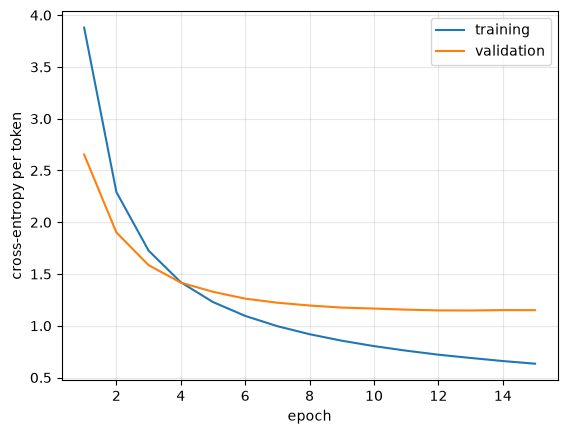

In [12]:
train_losses, validation_losses = zip(*history)
plt.plot(range(1, EPOCHS + 1), train_losses, label='training')
plt.plot(range(1, EPOCHS + 1), validation_losses, label='validation')
plt.xlabel('epoch')
plt.ylabel('cross-entropy per token')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Beam-search translation and attention

In [13]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

@torch.inference_mode()
def translate(
    sentence: str, max_steps: int = MAX_STEPS, beam_size: int = 4,
    length_penalty: float = 0.6,
):
    if not 1 <= beam_size <= len(mt_data.tgt_vocab) or length_penalty < 0:
        raise ValueError('beam_size must fit the vocabulary and length_penalty be non-negative')

    model.eval()
    tokens = mt_data.preprocess(sentence).strip().split() + ['<eos>']
    valid_length = min(len(tokens), max_steps)
    padded = tokens[:max_steps] + ['<pad>'] * max(0, max_steps - len(tokens))
    source = torch.tensor([mt_data.src_vocab[padded]], device=DEVICE)
    source_lengths = torch.tensor([valid_length], device=DEVICE)
    state = decoder.init_state(encoder(source, source_lengths), source_lengths)
    bos_index = mt_data.tgt_vocab['<bos>']
    eos_index = mt_data.tgt_vocab['<eos>']
    pad_index = mt_data.tgt_vocab['<pad>']
    beams = [([bos_index], 0.0, state, [])]

    def normalized_score(beam):
        generated_length = max(1, len(beam[0]) - 1)
        return beam[1] / (((5 + generated_length) / 6) ** length_penalty)

    for _ in range(max_steps):
        candidates = []
        for token_indices, score, beam_state, weights in beams:
            if token_indices[-1] == eos_index:
                candidates.append((token_indices, score, beam_state, weights))
                continue

            decoder_input = torch.tensor([[token_indices[-1]]], device=DEVICE)
            logits, next_state = decoder(decoder_input, beam_state)
            log_probabilities = torch.log_softmax(logits[0, -1], dim=-1)
            log_probabilities[[bos_index, pad_index]] = -torch.inf
            top_scores, top_indices = log_probabilities.topk(beam_size)
            attention_weight = decoder.attention_weights[-1][0, 0].cpu()

            for log_probability, next_index in zip(
                top_scores.cpu().tolist(), top_indices.cpu().tolist()
            ):
                candidates.append((
                    [*token_indices, next_index],
                    score + log_probability,
                    next_state,
                    [*weights, attention_weight],
                ))

        beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]
        if all(beam[0][-1] == eos_index for beam in beams):
            break

    best_indices, _, _, best_weights = max(beams, key=normalized_score)
    output_tokens = []
    weights = []
    for index, weight in zip(best_indices[1:], best_weights):
        if index == eos_index:
            break
        output_tokens.append(mt_data.tgt_vocab.to_tokens(index))
        weights.append(weight)

    translation = ' '.join(output_tokens)
    for punctuation in ',.!?':
        translation = translation.replace(f' {punctuation}', punctuation)
    attention = torch.stack(weights) if weights else torch.empty((0, max_steps))
    return translation, tokens[:valid_length], output_tokens, attention[:, :valid_length]

sentences = [
    "I am tired.",
    "I am happy.",
    "He is my friend.",
    "She went home.",
    "I like this book.",
    "Where is the station?",
    "I went to the market.",
    "My friend called me yesterday.",
    "I bought some fruit this morning.",
    "The weather is nice today.",
    "I want to walk in the park.",
    "We are going to school.",
    "She is reading a book.",
    "He likes to drink coffee.",
    "They are playing outside.",
    "I saw him yesterday.",
    "We will meet tomorrow.",
    "The train is late.",
    "I do not understand.",
    "Can you help me?",
    "I went to the market this morning.",
    "I bought some fruit and came home.",
    "My friend called me yesterday and asked me to come.",
    "The weather is nice today, so I want to walk in the park.",
    "We decided to meet at the station tomorrow.",
]

for sentence in sentences:
    greedy_translation, _, _, _ = translate(sentence, beam_size=1)
    beam_translation, source_words, target_words, attention = translate(
        sentence, beam_size=4
    )
    print(f'\n{sentence}')
    print(f'  greedy: {greedy_translation}')
    print(f'  beam:   {beam_translation}')


I am tired.
  greedy: je suis fatigué.
  beam:   je suis fatigué.

I am happy.
  greedy: je suis heureux.
  beam:   je suis heureux.

He is my friend.
  greedy: c'est mon ami.
  beam:   c'est mon ami.

She went home.
  greedy: elle est rentrée chez lui.
  beam:   elle est rentrée chez lui.

I like this book.
  greedy: j'aime ce livre.
  beam:   j'aime ce livre.

Where is the station?
  greedy: où se trouve la gare?
  beam:   où se trouve la gare?

I went to the market.
  greedy: je suis allé au marché.
  beam:   je suis allé au marché.

My friend called me yesterday.
  greedy: mon ami m'a appelé hier.
  beam:   mon ami m'a appelé hier.

I bought some fruit this morning.
  greedy: j'ai acheté quelques messages ce matin.
  beam:   j'ai acheté quelques messages ce matin.

The weather is nice today.
  greedy: aujourd'hui, il fait beau.
  beam:   aujourd'hui, il fait beau.

I want to walk in the park.
  greedy: je veux marcher dans le parc.
  beam:   je veux marcher dans le parc.

We are g

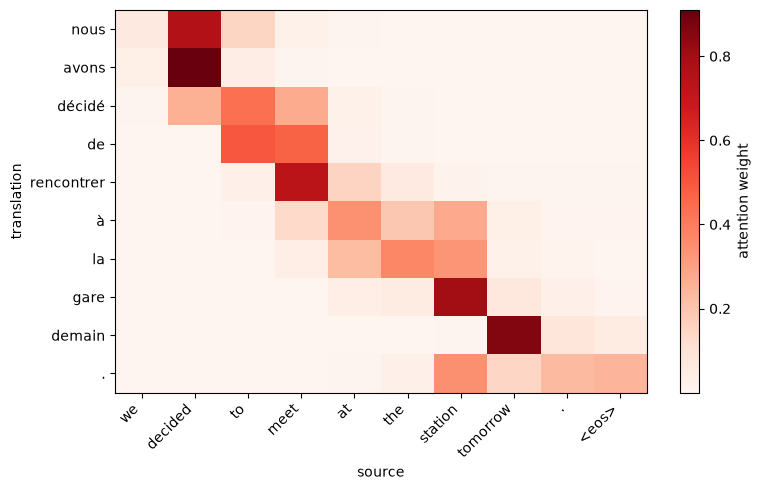

In [14]:
fig, ax = plt.subplots(figsize=(max(5, len(source_words) * 0.8), max(3, len(target_words) * 0.5)))
image = ax.imshow(attention.numpy(), cmap='Reds', aspect='auto')
ax.set_xticks(range(len(source_words)), source_words, rotation=45, ha='right')
ax.set_yticks(range(len(target_words)), target_words)
ax.set_xlabel('source')
ax.set_ylabel('translation')
fig.colorbar(image, ax=ax, label='attention weight')
plt.tight_layout()
plt.show()

## BLEU-4 evaluation

Evaluate greedy translations against the validation references with corpus BLEU-4 and add-one smoothing.

In [15]:
def corpus_bleu(references, candidates, max_n: int = 4) -> float:
    matches = [0] * max_n
    totals = [0] * max_n
    reference_length = candidate_length = 0

    for reference, candidate in zip(references, candidates):
        reference_length += len(reference)
        candidate_length += len(candidate)
        for n in range(1, max_n + 1):
            reference_ngrams = collections.Counter(
                tuple(reference[i:i + n]) for i in range(len(reference) - n + 1)
            )
            candidate_ngrams = collections.Counter(
                tuple(candidate[i:i + n]) for i in range(len(candidate) - n + 1)
            )
            matches[n - 1] += sum((reference_ngrams & candidate_ngrams).values())
            totals[n - 1] += sum(candidate_ngrams.values())

    if candidate_length == 0:
        return 0.0
    precisions = [
        (matches[i] + 1) / (totals[i] + 1)
        for i in range(max_n)
        if totals[i] > 0
    ]
    brevity_penalty = math.exp(min(0, 1 - reference_length / candidate_length))
    return 100 * brevity_penalty * math.exp(
        sum(math.log(precision) for precision in precisions) / len(precisions)
    )

@torch.inference_mode()
def evaluate_bleu(loader) -> float:
    model.eval()
    bos_index = mt_data.tgt_vocab['<bos>']
    eos_index = mt_data.tgt_vocab['<eos>']
    special_indices = {bos_index, eos_index, PAD_INDEX}
    references, candidates = [], []

    for source, source_lengths, target, _ in loader:
        source = source.to(DEVICE)
        source_lengths = source_lengths.to(DEVICE)
        state = decoder.init_state(encoder(source, source_lengths), source_lengths)
        decoder_input = torch.full(
            (source.shape[0], 1), bos_index, dtype=torch.long, device=DEVICE
        )
        batch_candidates = [[] for _ in range(source.shape[0])]
        finished = [False] * source.shape[0]

        for _ in range(MAX_STEPS):
            logits, state = decoder(decoder_input, state)
            next_indices = logits[:, -1].argmax(dim=-1)
            for i, index in enumerate(next_indices.tolist()):
                if not finished[i]:
                    if index == eos_index:
                        finished[i] = True
                    elif index not in special_indices:
                        batch_candidates[i].append(index)
            if all(finished):
                break
            decoder_input = next_indices.unsqueeze(1)

        candidates.extend(batch_candidates)
        for row in target.tolist():
            reference = []
            for index in row:
                if index == eos_index:
                    break
                if index not in special_indices:
                    reference.append(index)
            references.append(reference)

    return corpus_bleu(references, candidates)

bleu_score = evaluate_bleu(validation_loader)
print(f'Validation BLEU-4: {bleu_score:.2f}')

Validation BLEU-4: 41.09
